# Exercise 5.2: Error analysis and local evaluation

Error analysis on the official dev set: where does the (class-weighted) model fail? Comparison with baseline. Confusion matrix and example-based analysis for the report.

In [12]:
import ast
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load dev data and predictions

In [13]:
pcl = pd.read_csv(
    DATA_DIR / "dontpatronizeme_pcl.tsv",
    sep="\t",
    header=None,
    names=["id", "par_id", "keyword", "country", "text", "category"],
)
pcl["id"] = pcl["id"].astype(int)

def to_binary(label_str):
    vec = ast.literal_eval(label_str)
    return 1 if any(x == 1 for x in vec) else 0

dev_labels = pd.read_csv(DATA_DIR / "dev_semeval_parids-labels.csv")
dev_labels["binary_label"] = dev_labels["label"].apply(to_binary)

dev_df = pcl[pcl["id"].isin(dev_labels["par_id"])].copy()
dev_df = dev_df.merge(
    dev_labels[["par_id", "binary_label"]],
    left_on="id",
    right_on="par_id",
    how="inner",
)
dev_df = dev_df[["id", "text", "binary_label", "keyword"]]

def valid_text(x):
    return isinstance(x, str) and len(x.strip()) > 0

dev_df = dev_df[dev_df["text"].apply(valid_text)].reset_index(drop=True)

pred_ours = pd.read_csv(OUTPUT_DIR / "dev_class_weights_3epoch.csv")
pred_baseline = pd.read_csv(OUTPUT_DIR / "dev_baseline_1epoch.csv")

df = dev_df.merge(
    pred_ours[["id", "pred", "prob_pos"]].rename(columns={"pred": "pred_ours", "prob_pos": "prob_ours"}),
    on="id",
    how="inner",
)
df = df.merge(
    pred_baseline[["id", "pred"]].rename(columns={"pred": "pred_baseline"}),
    on="id",
    how="inner",
)
df = df.rename(columns={"binary_label": "gold"})

THRESHOLD = 0.6
df["pred_ours"] = (df["prob_ours"] >= THRESHOLD).astype(int)

print(f"Dev examples with predictions: {len(df)}")
print(f"Submitted system: threshold = {THRESHOLD} (same as dev.txt / test.txt)")
df.head()

Dev examples with predictions: 2093
Submitted system: threshold = 0.6 (same as dev.txt / test.txt)


,id,text,gold,keyword,pred_ours,prob_ours,pred_baseline
0,107,"His present "" chambers "" may be quite humble , but Shiyani has the tiny space very neatly organized and clean . Many people pass him by but do not manage to see him , because the space is partiall...",1,homeless,0,0.514989,0
1,149,"Krueger recently harnessed that creativity to self-publish a book featuring the poems , artwork , photography and short stories of 16 ill or disabled artists from around the world . She hopes the ...",1,disabled,1,0.636099,0
2,151,"10:41am - Parents of children who died must get compensation , free medicine must be provided to poor families across UP : Ram Gopal Yadav",1,poor-families,1,0.831270,0
3,154,"When some people feel causing problem for some others by breaking into their homes to steal is n't too good , they just result to begging . You now see people without deformities begging , when so...",1,disabled,1,0.863731,0
4,157,We are alarmed to learn of your recently circulated proposals that would eviscerate the Lifeline program and leave many of the most vulnerable people in the country without access to affordable co...,1,poor-families,1,0.711082,0


## Metrics and confusion matrix (our model)

All analysis below uses the **submitted** predictions (threshold = 0.6), matching dev.txt and test.txt.

In [14]:
gold = df["gold"].values
pred = df["pred_ours"].values

print("Classification report (our model):")
print(classification_report(gold, pred, target_names=["No PCL", "PCL"], digits=4))
print(f"F1 (positive class): {f1_score(gold, pred, pos_label=1):.4f}")
print(f"Precision (PCL): {precision_score(gold, pred, pos_label=1):.4f}")
print(f"Recall (PCL): {recall_score(gold, pred, pos_label=1):.4f}")

Classification report (our model):
              precision    recall  f1-score   support

      No PCL     0.9732    0.8823    0.9255      1894
         PCL     0.4069    0.7688    0.5322       199

    accuracy                         0.8715      2093
   macro avg     0.6901    0.8256    0.7288      2093
weighted avg     0.9194    0.8715    0.8881      2093

F1 (positive class): 0.5322
Precision (PCL): 0.4069
Recall (PCL): 0.7688


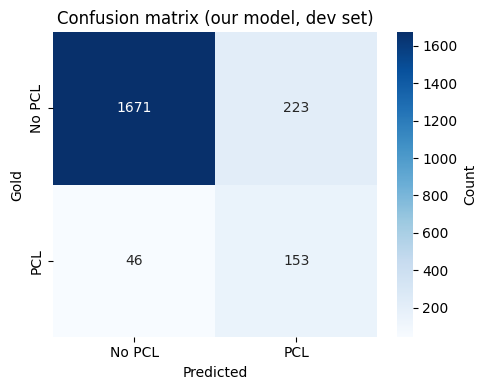

In [15]:
cm = confusion_matrix(gold, pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No PCL", "PCL"],
    yticklabels=["No PCL", "PCL"],
    ax=ax,
    cbar_kws={"label": "Count"},
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Gold")
ax.set_title("Confusion matrix (our model, dev set)")
plt.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Comparison with baseline

In [16]:
df["ours_correct"] = (df["pred_ours"] == df["gold"]).astype(int)
df["baseline_correct"] = (df["pred_baseline"] == df["gold"]).astype(int)

both_correct = df[(df["ours_correct"] == 1) & (df["baseline_correct"] == 1)]
both_wrong = df[(df["ours_correct"] == 0) & (df["baseline_correct"] == 0)]
ours_right_baseline_wrong = df[(df["ours_correct"] == 1) & (df["baseline_correct"] == 0)]
ours_wrong_baseline_right = df[(df["ours_correct"] == 0) & (df["baseline_correct"] == 1)]

print("Comparison with baseline (dev set):")
print(f"  Both correct:           {len(both_correct):5d}")
print(f"  Both wrong:             {len(both_wrong):5d}")
print(f"  Ours right, baseline wrong: {len(ours_right_baseline_wrong):5d}")
print(f"  Ours wrong, baseline right: {len(ours_wrong_baseline_right):5d}")

Comparison with baseline (dev set):
  Both correct:            1671
  Both wrong:                46
  Ours right, baseline wrong:   153
  Ours wrong, baseline right:   223


## Error analysis: False positives and False negatives

Our model predicts PCL but gold is No PCL (FP), or predicts No PCL but gold is PCL (FN).

In [17]:
fp = df[(df["gold"] == 0) & (df["pred_ours"] == 1)]
fn = df[(df["gold"] == 1) & (df["pred_ours"] == 0)]

print(f"False positives (model said PCL, gold No PCL): {len(fp)}")
print(f"False negatives (model said No PCL, gold PCL): {len(fn)}")
print()
print("FP by keyword:")
print(fp["keyword"].value_counts())
print()
print("FN by keyword:")
print(fn["keyword"].value_counts())

False positives (model said PCL, gold No PCL): 223
False negatives (model said No PCL, gold PCL): 46

FP by keyword:
keyword
poor-families    39
in-need          39
homeless         34
hopeless         24
disabled         21
vulnerable       21
women            20
refugee          14
immigrant         7
migrant           4
Name: count, dtype: int64

FN by keyword:
keyword
hopeless         10
homeless          8
poor-families     8
women             5
disabled          4
refugee           3
immigrant         3
vulnerable        3
migrant           2
Name: count, dtype: int64


### Sample false positives (model predicted PCL, gold = No PCL)


In [18]:
pd.set_option("display.max_colwidth", 200)
sample_fp = fp.sample(min(10, len(fp)), random_state=42)[["keyword", "text", "prob_ours"]]
for i, row in sample_fp.iterrows():
    print(f"--- keyword: {row['keyword']} | prob_pos: {row['prob_ours']:.3f} ---")
    print(row["text"][:500] + ("..." if len(str(row["text"])) > 500 else ""))
    print()

--- keyword: disabled | prob_pos: 0.765 ---
Accessibility and the rights of disabled New Zealanders , people with access needs , older people and anyone who is currently struggling to access the world around them , is the social movement of our time .

--- keyword: women | prob_pos: 0.813 ---
Geeta and the other women in their Self Help Group are also proud of the fact that other women are also getting inspired by their progress story . More and more women are getting associated with Bihan with an aim to bring about positive changes in their lives and most of them are inspired by other women who have already shown the example .

--- keyword: in-need | prob_pos: 0.959 ---
Christmas is celebration of the birth of not merely a child , but a child who changed the destiny of humans forever . It is celebration of the fact that God wanted to be a part of the human race and so he took on flesh and blood and became human like us . We can also show unconditional love through our good deeds and h

### Sample false negatives (model predicted No PCL, gold = PCL)

In [19]:
sample_fn = fn.sample(min(10, len(fn)), random_state=42)[["keyword", "text", "prob_ours"]]
for i, row in sample_fn.iterrows():
    print(f"--- keyword: {row['keyword']} | prob_pos: {row['prob_ours']:.3f} ---")
    print(row["text"][:500] + ("..." if len(str(row["text"])) > 500 else ""))
    print()

--- keyword: women | prob_pos: 0.583 ---
" Jesus is the Master Feminist because he championed the cause of women , " she said .

--- keyword: hopeless | prob_pos: 0.437 ---
The indigenous Palestinians see themselves abandoned by the powerful nations of the UN . In sheer hopelessness and a sense of dehumization they are , regrettably , now resorting to nihilistic activities trying to harm Israeli Jews and getting killed every day by the trigger happy Israelis - civilians and security forces alike . It is a sad development in a region that has cried for justice for too long -- almost 70 years - only to be ignored and severely punished for their noncompliance to the Z...

--- keyword: refugee | prob_pos: 0.583 ---
IdeaRaya spokesman Maryam Ramli Lee in an interview with Malay Mail Online , September 10 , 2015 . For human rights , Idearaya is shining a spotlight on marginalised communities such as refugees and migrant workers , while its focus for philosophy this year would be on educating

### Examples where we beat the baseline

In [20]:
sample_win = ours_right_baseline_wrong.sample(min(5, len(ours_right_baseline_wrong)), random_state=42)
for i, row in sample_win.iterrows():
    print(f"--- gold: {row['gold']} | keyword: {row['keyword']} ---")
    print(row["text"][:400] + ("..." if len(str(row["text"])) > 400 else ""))
    print()

--- gold: 1 | keyword: in-need ---
" I have a lot of sympathy for folks who are in need in the city , " Mr Edmonds-Waters said . " This has become an extremely expensive city to live in . The divide between those who have and those who do n't is ridiculously ginormous . "

--- gold: 1 | keyword: poor-families ---
KOLKATA : Sourav Kaibartya , a fisherman 's son who scored 94.2% in his higher secondary examination this year got entry into NIT Durgapur for engineering course . The boy was at a loss as to who will fund his education . That is when a corporate house came into his rescue . Thirty-seven students like him from West Bengal meritorious but from poor families will now get to continue their studies wi...

--- gold: 1 | keyword: in-need ---
Kenyans are known to have big hearts . Hearts so big that they give generously when it comes those in need . Despite all our differences , we unite to help the sick , fight for justice or feed those in drought or war-stricken areas .

--- gold: 

### Examples where baseline beat us

Baseline correct, our model wrong (possible over-correction toward PCL from class weighting).

In [21]:
sample_lose = ours_wrong_baseline_right.sample(min(5, len(ours_wrong_baseline_right)), random_state=42)
for i, row in sample_lose.iterrows():
    print(f"--- gold: {row['gold']} | keyword: {row['keyword']} | prob_ours: {row['prob_ours']:.3f} ---")
    print(row["text"][:400] + ("..." if len(str(row["text"])) > 400 else ""))
    print()

--- gold: 0 | keyword: disabled | prob_ours: 0.765 ---
Accessibility and the rights of disabled New Zealanders , people with access needs , older people and anyone who is currently struggling to access the world around them , is the social movement of our time .

--- gold: 0 | keyword: women | prob_ours: 0.813 ---
Geeta and the other women in their Self Help Group are also proud of the fact that other women are also getting inspired by their progress story . More and more women are getting associated with Bihan with an aim to bring about positive changes in their lives and most of them are inspired by other women who have already shown the example .

--- gold: 0 | keyword: in-need | prob_ours: 0.959 ---
Christmas is celebration of the birth of not merely a child , but a child who changed the destiny of humans forever . It is celebration of the fact that God wanted to be a part of the human race and so he took on flesh and blood and became human like us . We can also show unconditional 